# PII NER Baseline Analysis (WikiAnn EN + ZH Test)

This notebook analyzes the **off-the-shelf NER baseline** used for Phase 1 model selection.

Canonical run artifact:
- `data/runs/pii_eval/pii_eval_wikiann_baseline_v1/summary.json`

Scope:
- Dataset: WikiAnn EN/ZH
- Splits analyzed: `en_test`, `zh_test`
- Entities: `PER`, `ORG`, `LOC`
- Scoring: strict entity-level precision/recall/F1/F2 (`beta=2.0`)


## How To Interpret This Notebook

Before reading numbers, keep these rules in mind:
- This is a **baseline** run with no task-specific fine-tuning on your gold set.
- For privacy-oriented PII detection, **recall/F2** usually matters more than precision/F1.
- Test-split metrics are for reporting/model selection; avoid overfitting decisions to this one benchmark.
- WikiAnn labels are a proxy for PII-like entities (PER/ORG/LOC), not your final curated KPI set.


In [1]:
from __future__ import annotations

import csv
import json
from pathlib import Path
from collections import defaultdict

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

def read_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8'))

def read_jsonl(path: Path):
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def read_csv(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return list(csv.DictReader(f))

def as_float(x, default=0.0):
    try:
        return float(x)
    except Exception:
        return float(default)

def as_int(x, default=0):
    try:
        return int(x)
    except Exception:
        return int(default)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('pandas available:', pd is not None)
print('matplotlib available:', plt is not None)


PROJECT_ROOT = /home/shoo/personal/dlDev/school/AAI3008-multilingual-PII-masking
pandas available: False
matplotlib available: True


## 1) Load Canonical Evaluation Run

In [2]:
RUN_ID = 'pii_eval_wikiann_baseline_v1'
RUN_DIR = PROJECT_ROOT / 'data' / 'runs' / 'pii_eval' / RUN_ID

summary_path = RUN_DIR / 'summary.json'
per_split_path = RUN_DIR / 'per_split.csv'
per_type_path = RUN_DIR / 'per_type.csv'
per_item_path = RUN_DIR / 'per_item.jsonl'

required = [summary_path, per_split_path, per_type_path, per_item_path]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError('Missing expected artifacts:\n- ' + '\n- '.join(missing))

summary = read_json(summary_path)
per_split = read_csv(per_split_path)
per_type = read_csv(per_type_path)
per_item = read_jsonl(per_item_path)

print('run:', summary.get('run_id'))
print('created_at:', summary.get('created_at'))
print('num_splits:', len(summary.get('splits', [])))
print('num_sentences:', summary.get('overall', {}).get('num_sentences'))


run: pii_eval_wikiann_baseline_v1
created_at: 2026-02-21T08:09:04.037673+00:00
num_splits: 2
num_sentences: 20000


## 2) Run-Level Snapshot

This section gives headline metrics for model selection.


In [3]:
overall = summary.get('overall', {})
headline = {
    'precision': as_float(overall.get('precision')),
    'recall': as_float(overall.get('recall')),
    'f1': as_float(overall.get('f1')),
    'f2': as_float(overall.get('fbeta')),
    'token_accuracy': as_float(overall.get('token_accuracy')),
    'tp': as_int(overall.get('tp')),
    'fp': as_int(overall.get('fp')),
    'fn': as_int(overall.get('fn')),
}

if pd is not None:
    display(pd.DataFrame([headline]))
    display(pd.DataFrame(per_split))
else:
    print('Overall:', headline)
    print('Per-split rows:')
    for r in per_split:
        print(r)


Overall: {'precision': 0.3962347450411529, 'recall': 0.47432993582483957, 'f1': 0.43177952268861364, 'f2': 0.4563415679409607, 'token_accuracy': 0.7625829045516292, 'tp': 12565, 'fp': 19146, 'fn': 13925}
Per-split rows:
{'split': 'en_test', 'lang': 'en', 'num_sentences': '10000', 'token_accuracy': '0.7298384084854219', 'tp': '6826', 'fp': '7624', 'fn': '7132', 'precision': '0.47238754325259513', 'recall': '0.4890385442040407', 'f1': '0.48056885384398756', 'fbeta': '0.48561509348054976', 'beta': '2.0'}
{'split': 'zh_test', 'lang': 'zh', 'num_sentences': '10000', 'token_accuracy': '0.7752584275077709', 'tp': '5739', 'fp': '11522', 'fn': '6793', 'precision': '0.3324836336249348', 'recall': '0.4579476540057453', 'f1': '0.385258282146813', 'fbeta': '0.4258113341940079', 'beta': '2.0'}


### 2.1) Entity-Type Breakdown

Read this table to identify where errors concentrate by `PER/ORG/LOC` and language split.


In [4]:
for r in per_type:
    for k in ['support','tp','fp','fn']:
        r[k] = as_int(r.get(k))
    for k in ['precision','recall','f1','fbeta']:
        r[k] = as_float(r.get(k))

if pd is not None:
    df_type = pd.DataFrame(per_type)
    display(df_type.sort_values(['split','entity_type']))

    macro = (
        df_type.groupby('split')[['f1','fbeta']]
        .mean()
        .rename(columns={'f1':'macro_f1','fbeta':'macro_f2'})
        .reset_index()
    )
    print('Macro averages by split:')
    display(macro)

    weighted_rows = []
    for split, g in df_type.groupby('split'):
        support = g['support'].sum()
        weighted_f1 = (g['f1'] * g['support']).sum() / support
        weighted_f2 = (g['fbeta'] * g['support']).sum() / support
        weighted_rows.append({
            'split': split,
            'weighted_f1': weighted_f1,
            'weighted_f2': weighted_f2,
            'entity_support': int(support),
        })
    print('Support-weighted averages by split:')
    display(pd.DataFrame(weighted_rows))
else:
    print('per_type rows:', per_type)


per_type rows: [{'split': 'en_test', 'entity_type': 'LOC', 'support': 4657, 'tp': 2287, 'fp': 3701, 'fn': 2370, 'precision': 0.3819305277221109, 'recall': 0.491088683701954, 'f1': 0.42968529826209484, 'fbeta': 0.46453526161845954, 'beta': '2.0'}, {'split': 'en_test', 'entity_type': 'ORG', 'support': 4745, 'tp': 1420, 'fp': 1332, 'fn': 3325, 'precision': 0.5159883720930233, 'recall': 0.2992623814541623, 'f1': 0.37881819394424443, 'fbeta': 0.3267071599484631, 'beta': '2.0'}, {'split': 'en_test', 'entity_type': 'PER', 'support': 4556, 'tp': 3119, 'fp': 2591, 'fn': 1437, 'precision': 0.5462346760070053, 'recall': 0.6845917471466199, 'f1': 0.6076368595363336, 'fbeta': 0.6515835213503802, 'beta': '2.0'}, {'split': 'zh_test', 'entity_type': 'LOC', 'support': 4474, 'tp': 2520, 'fp': 5731, 'fn': 1954, 'precision': 0.3054175251484669, 'recall': 0.5632543585158695, 'f1': 0.39607072691552064, 'fbeta': 0.4818908478984204, 'beta': '2.0'}, {'split': 'zh_test', 'entity_type': 'ORG', 'support': 4115, '

## 3) Error Profile (Sentence-Level)

This section uses `per_item.jsonl` to quantify practical behavior:
- how often the model predicts nothing when entities exist
- sentence-level perfect-match rate
- FP vs FN balance


In [5]:
grouped = defaultdict(list)
for r in per_item:
    grouped[r.get('split','unknown')].append(r)

profile_rows = []
for split, rows in sorted(grouped.items()):
    n = len(rows)
    gold_positive = sum(1 for r in rows if as_int(r.get('gold_entities')) > 0)
    pred_positive = sum(1 for r in rows if as_int(r.get('pred_entities')) > 0)
    miss_all = sum(1 for r in rows if as_int(r.get('gold_entities')) > 0 and as_int(r.get('pred_entities')) == 0)
    perfect = sum(1 for r in rows if as_int(r.get('fp')) == 0 and as_int(r.get('fn')) == 0)

    tp = sum(as_int(r.get('tp')) for r in rows)
    fp = sum(as_int(r.get('fp')) for r in rows)
    fn = sum(as_int(r.get('fn')) for r in rows)

    profile_rows.append({
        'split': split,
        'sentences': n,
        'predicted_any_rate': pred_positive / n if n else 0.0,
        'missed_all_rate_given_gold': miss_all / gold_positive if gold_positive else 0.0,
        'sentence_perfect_rate': perfect / n if n else 0.0,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'fn_to_tp_ratio': (fn / tp) if tp else None,
        'fp_to_tp_ratio': (fp / tp) if tp else None,
    })

if pd is not None:
    display(pd.DataFrame(profile_rows))
else:
    for r in profile_rows:
        print(r)


{'split': 'en_test', 'sentences': 10000, 'predicted_any_rate': 0.8689, 'missed_all_rate_given_gold': 0.1311, 'sentence_perfect_rate': 0.3389, 'tp': 6826, 'fp': 7624, 'fn': 7132, 'fn_to_tp_ratio': 1.0448285965426312, 'fp_to_tp_ratio': 1.1169059478464693}
{'split': 'zh_test', 'sentences': 10000, 'predicted_any_rate': 0.8441, 'missed_all_rate_given_gold': 0.1559, 'sentence_perfect_rate': 0.337, 'tp': 5739, 'fp': 11522, 'fn': 6793, 'fn_to_tp_ratio': 1.1836556891444503, 'fp_to_tp_ratio': 2.007666840913051}


### 3.1) FP vs FN Balance Chart

For privacy-sensitive usage, high FN (missed entities) is usually the bigger risk.


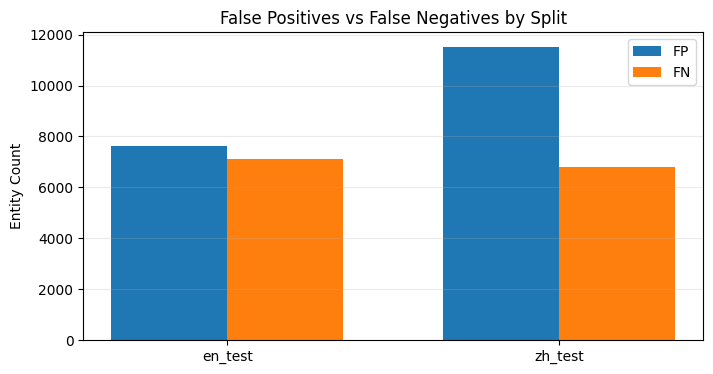

In [6]:
if plt is None:
    print('matplotlib not available; skipping chart')
else:
    labels = [r['split'] for r in profile_rows]
    fps = [r['fp'] for r in profile_rows]
    fns = [r['fn'] for r in profile_rows]

    x = list(range(len(labels)))
    w = 0.35
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar([i - w/2 for i in x], fps, width=w, label='FP')
    ax.bar([i + w/2 for i in x], fns, width=w, label='FN')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Entity Count')
    ax.set_title('False Positives vs False Negatives by Split')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)
    plt.show()


## 4) Hard-Case Inspection

This surfaces the worst samples by missed entities (`fn`) and false positives (`fp`).


In [7]:
top_fn = sorted(per_item, key=lambda r: (as_int(r.get('fn')), as_int(r.get('token_count'))), reverse=True)[:10]
top_fp = sorted(per_item, key=lambda r: (as_int(r.get('fp')), as_int(r.get('token_count'))), reverse=True)[:10]

# Index raw test records for readable context
index = {}
for raw_path in [
    PROJECT_ROOT / 'data' / 'raw' / 'wikiann' / 'en' / 'test.jsonl',
    PROJECT_ROOT / 'data' / 'raw' / 'wikiann' / 'zh' / 'test.jsonl',
]:
    for rec in read_jsonl(raw_path):
        index[rec.get('item_id')] = rec

def preview(rows):
    out = []
    for r in rows:
        item_id = r.get('item_id')
        rec = index.get(item_id, {})
        toks = rec.get('tokens', [])
        txt = ' '.join(toks[:40]) + (' ...' if len(toks) > 40 else '')
        out.append({
            'item_id': item_id,
            'split': r.get('split'),
            'token_count': as_int(r.get('token_count')),
            'gold_entities': as_int(r.get('gold_entities')),
            'pred_entities': as_int(r.get('pred_entities')),
            'tp': as_int(r.get('tp')),
            'fp': as_int(r.get('fp')),
            'fn': as_int(r.get('fn')),
            'token_preview': txt,
        })
    return out

fn_preview = preview(top_fn)
fp_preview = preview(top_fp)

if pd is not None:
    print('Top FN samples')
    display(pd.DataFrame(fn_preview))
    print('Top FP samples')
    display(pd.DataFrame(fp_preview))
else:
    print('Top FN samples')
    for r in fn_preview:
        print(r)
    print('Top FP samples')
    for r in fp_preview:
        print(r)


Top FN samples
{'item_id': 'en_test_00003491', 'split': 'en_test', 'token_count': 73, 'gold_entities': 30, 'pred_entities': 32, 'tp': 0, 'fp': 32, 'fn': 30, 'token_preview': 'Pa Tang | Padamrud | Padehay | Padehkeh | Pahnai | Pahvaz | Panhani | Pardan | Pariabad | Parmich | Patak-e Pain | Payehan | Pedaran-e Olya | Pedaran-e Sofla | Pespatang-e Sofla | Pesteh | Pey Rud | ...'}
{'item_id': 'en_test_00001628', 'split': 'en_test', 'token_count': 51, 'gold_entities': 23, 'pred_entities': 0, 'tp': 0, 'fp': 0, 'fn': 23, 'token_preview': 'A - B - C - D - E - F - G - H - I - J - K - L - M - N - O - P - Q - R - S - T - ...'}
{'item_id': 'en_test_00005092', 'split': 'en_test', 'token_count': 29, 'gold_entities': 15, 'pred_entities': 15, 'tp': 0, 'fp': 15, 'fn': 15, 'token_preview': 'Lawrence , Johnson , Martin , Magoffin , Floyd , Pike , Letcher , Harlan , Bell , Breathitt , Leslie , Perry , Knott , Wolfe , Powell'}
{'item_id': 'zh_test_00000046', 'split': 'zh_test', 'token_count': 207, 'gold_en

## 5) Visual Summary (Per-Type F1/F2)

Compact chart for report slides: compare per-type quality across EN and ZH.


In [8]:
if plt is None or pd is None:
    print('pandas/matplotlib not available; skipping chart')
else:
    df = pd.DataFrame(per_type)
    for c in ['f1','fbeta']:
        df[c] = df[c].astype(float)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, metric, title in [
        (axes[0], 'f1', 'Per-Type F1'),
        (axes[1], 'fbeta', 'Per-Type F2 (beta=2.0)'),
    ]:
        pivot = df.pivot(index='entity_type', columns='split', values=metric).fillna(0.0)
        pivot.plot(kind='bar', ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Entity Type')
        ax.set_ylabel(metric.upper())
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


pandas/matplotlib not available; skipping chart


## 6) Phase 1 Decision Notes

Use this checklist to close Phase 1:
- Baseline run is complete on fixed public test splits.
- Performance is stronger on `PER`, weaker on `ORG` (especially ZH).
- Recall/F2 are below privacy-grade targets, so this should be treated as a baseline anchor only.
- Next phase should move to curated gold-set evaluation and task-specific improvement.


## 7) Findings Summary and Hypotheses

### Findings
- Baseline quality is moderate for an off-the-shelf multilingual model, but not privacy-grade yet.
- Overall (`en_test` + `zh_test`): Precision `0.396`, Recall `0.474`, F1 `0.432`, F2 `0.456`.
- EN is stronger than ZH:
  - EN: F1 `0.481`, F2 `0.486`
  - ZH: F1 `0.385`, F2 `0.426`
- Entity-type pattern is consistent:
  - `PER` is strongest.
  - `ORG` is weakest (notably ZH ORG F1 `0.193`).
- Sentence-level exact outcomes remain limited:
  - perfect (FP=0 and FN=0) is about `33.8%` for EN and `33.7%` for ZH.
  - full-miss among gold-positive sentences is `13.1%` (EN) and `15.6%` (ZH).

### Hypotheses For Error Sources
- Strict entity-level matching penalizes span-boundary mismatches heavily (one boundary miss can create both FP and FN).
- ORG strings are often long, list-like, and punctuation-heavy; this raises boundary/type confusion.
- ZH performance is likely affected by mixed-script/format artifacts and harder segmentation contexts.
- Current threshold setting (`score_threshold: 0.0`) likely increases false positives, especially in ZH.
- Off-the-shelf domain mismatch: WikiAnn style and project speech-PII style are not identical.

### Project Implication
- This is a valid Phase 1 baseline anchor for model selection.
- It should not be treated as final PII quality for deployment-like privacy claims.
- Next-phase evaluation should prioritize project-defined PII (`NAME`, `PHONE`, `EMAIL`, `ID_LIKE`, `ADDRESS_LIKE`) on curated gold data.
- Expected next improvement path: cue/rule + NER hybrid and gold-set adaptation/fine-tuning.
